

---

# ***`Missing Indicator - Random Sample Imputation`***

---



#### **Import Libraries**

In [ ]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings('ignore')

#### **Load the dataset**

In [45]:
df = pd.read_csv(
    r"https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/refs/heads/main/day38-missing-indicator/train.csv",
    usecols=["Age","Fare","Survived"]
)

df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [46]:
# check missing values
df.isnull().mean()*100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [47]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [48]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=2,
)

In [49]:
X_train['Age_imputed'] = X_train['Age'] 
X_test['Age_imputed'] = X_test['Age'] 

In [50]:
X_train.tail()

,Age,Fare,Age_imputed
534,30.0,8.6625,30.0
584,NaN,8.7125,NaN
493,71.0,49.5042,71.0
527,NaN,221.7792,NaN
168,NaN,25.9250,NaN


### **Numerical Data Random Sample Imputation**

In [51]:
# Impute missing values in 'Age_imputed' for training set using random samples from non-null 'Age'
X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

# Impute missing values in 'Age_imputed' for test set using random samples from non-null 'Age' in training set
X_test['Age_imputed'][X_test['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

In [52]:
X_train.sample(6)

,Age,Fare,Age_imputed
110,47.0,52.000,47.0
722,34.0,13.000,34.0
379,19.0,7.775,19.0
126,NaN,7.750,26.0
71,16.0,46.900,16.0
863,NaN,69.550,19.0


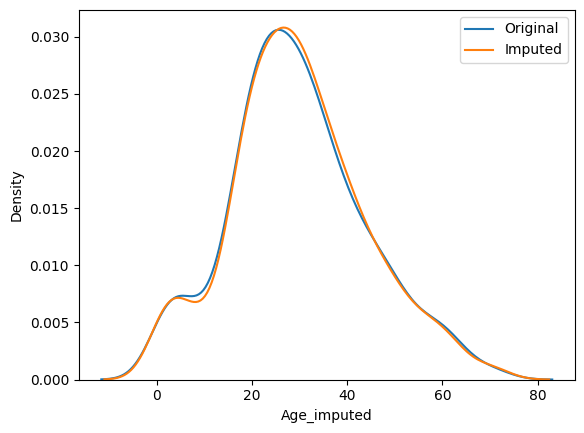

In [53]:

sns.distplot(X_train['Age'],label='Original',hist=False)
sns.distplot(X_train['Age_imputed'],label = 'Imputed',hist=False)

plt.legend()
plt.show()

In [54]:
# check differences of variance
print('\nOriginal variable variance: ', X_train['Age'].var())
print('\nVariance after random imputation: ', X_train['Age_imputed'].var())


Original variable variance:  204.34951339046142

Variance after random imputation:  201.06422096430097


In [55]:
# check differences of co-variance
X_train[['Fare', 'Age', 'Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,59.097188
Age,71.512440,204.349513,204.349513
Age_imputed,59.097188,204.349513,201.064221


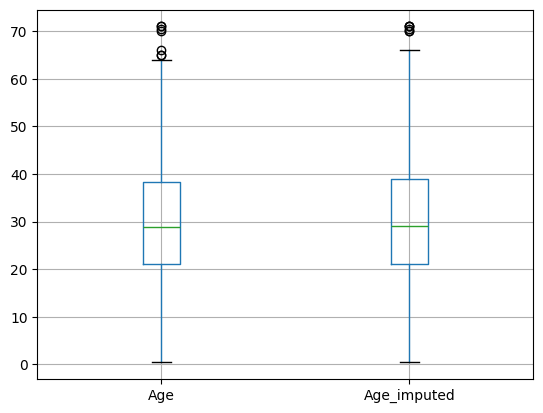

In [56]:
# check outliers before and after imputation
X_train[['Age', 'Age_imputed']].boxplot()
plt.show()

In [57]:
# Define an observation from X_train
observation = X_train.iloc[0]

# Randomly sample one non-null value from 'Age' in the training set, using 'Fare' as the seed for reproducibility
sampled_value = X_train['Age'].dropna().sample(1, random_state=int(observation['Fare']))

### **Categorical Data Random Sample Imputation**

In [58]:
data = pd.read_csv(
    r"https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/refs/heads/main/day38-missing-indicator/house-train.csv",
    usecols=['GarageQual','FireplaceQu', 'SalePrice']
)
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [59]:
# calculate missing values
data.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [60]:
X = data
y = data['SalePrice']

In [61]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)


In [62]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [63]:
X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values

X_train['FireplaceQu_imputed'][X_train['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
X_test['FireplaceQu_imputed'][X_test['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values

In [64]:
temp = pd.concat(
        [
            X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
            X_train['GarageQual_imputed'].value_counts() / len(X_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

In [65]:
temp

,original,imputed
TA,0.951043,0.950342
Fa,0.037171,0.036815
Gd,0.009973,0.011130
Po,0.000907,0.000856
Ex,0.000907,0.000856


- Since small difference in values so we can use this imputation here.

In [66]:
temp = pd.concat(
        [
            X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
            X_train['FireplaceQu_imputed'].value_counts() / len(df)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

temp

,original,imputed
Gd,0.494272,0.648709
TA,0.412439,0.539843
Fa,0.040917,0.052750
Po,0.027823,0.035915
Ex,0.024550,0.033670


In [67]:
temp

,original,imputed
Gd,0.494272,0.648709
TA,0.412439,0.539843
Fa,0.040917,0.052750
Po,0.027823,0.035915
Ex,0.024550,0.033670


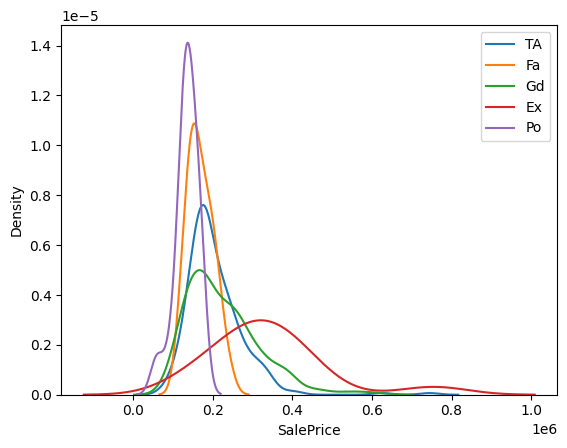

In [68]:
# Loop through each unique category in 'FireplaceQu' (excluding NaN values)
for category in X_train['FireplaceQu'].dropna().unique():
    # Plot the distribution of 'SalePrice' for each category without the histogram
    sns.distplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'], hist=False, label=category)
plt.legend()
# Display the plot
plt.show()

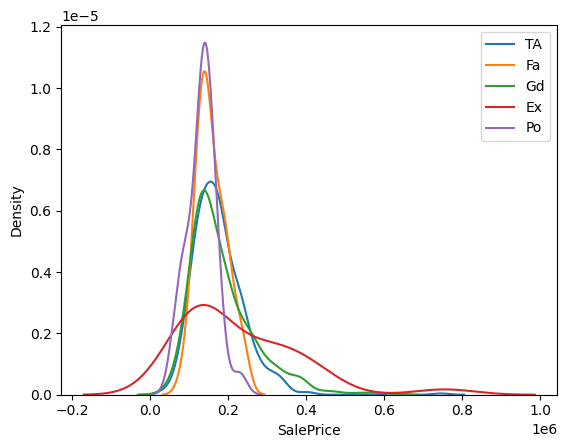

In [69]:
for category in X_train['FireplaceQu_imputed'].dropna().unique():
    sns.distplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],hist=False,label=category)
plt.legend()
plt.show()

### **Missing Indicater**
- Create a Seperate column for missing values

In [70]:
df = pd.read_csv(
    r"https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/refs/heads/main/day38-missing-indicator/train.csv",
    usecols=["Age","Fare","Survived"]
)

df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [71]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [72]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=2,
)

In [73]:
X_train.head()

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458


#### **Without using Missing Indicater Technique**

In [74]:
si = SimpleImputer()
X_train_trf = si.fit_transform(X_train)
X_test_trf = si.transform(X_test)

In [75]:
X_train_trf

array([[ 40.        ,  27.7208    ],
       [  4.        ,  16.7       ],
       [ 47.        ,   9.        ],
       ...,
       [ 71.        ,  49.5042    ],
       [ 29.78590426, 221.7792    ],
       [ 29.78590426,  25.925     ]])

In [76]:
clf = LogisticRegression()

clf.fit(X_train_trf,y_train)

y_pred = clf.predict(X_test_trf)

accuracy_score(y_test,y_pred)

0.6145251396648045

In [78]:
from sklearn.impute import MissingIndicator  # Import MissingIndicator to identify missing values

# Initialize the MissingIndicator to identify missing values
mi = MissingIndicator()

# Fit the MissingIndicator to the training data to learn the missingness patterns
mi.fit(X_train)

MissingIndicator()

In [79]:
mi.features_

array([0], dtype=int64)

In [80]:
X_train_missing = mi.transform(X_train)
X_test_missing = mi.transform(X_test)

In [81]:
X_train['Age_NA'] = X_train_missing

In [83]:
X_train.sample(6)

,Age,Fare,Age_NA
388,NaN,7.7292,True
543,32.0,26.0000,False
151,22.0,66.6000,False
715,19.0,7.6500,False
418,30.0,13.0000,False
203,45.5,7.2250,False


In [82]:
X_test['Age_NA'] = X_test_missing

In [84]:
# Initialize the SimpleImputer to replace missing values
si = SimpleImputer()

# Fit the imputer on the training data and transform it to fill missing values
X_train_trf2 = si.fit_transform(X_train)

# Transform the test data using the fitted imputer to ensure consistency
X_test_trf2 = si.transform(X_test)

In [85]:
clf = LogisticRegression()

clf.fit(X_train_trf2,y_train)

y_pred = clf.predict(X_test_trf2)

accuracy_score(y_test,y_pred)

0.6312849162011173

In [86]:
# to use MissingIndicater using SimpleImputer
si = SimpleImputer(add_indicator=True)

In [87]:
X_train = si.fit_transform(X_train)

In [88]:
X_test = si.transform(X_test)

In [89]:
clf = LogisticRegression()

clf.fit(X_train_trf2,y_train)

y_pred = clf.predict(X_test_trf2)

accuracy_score(y_test,y_pred)

0.6312849162011173

### **Automatically Select Value for Imputation**

In [92]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
)
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
)

import warnings
warnings.filterwarnings('ignore')

In [94]:
df = pd.read_csv(
    r"https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/refs/heads/main/day38-missing-indicator/train.csv",
)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [95]:
# drop these 4 columns
df.drop(columns=['PassengerId','Name','Ticket','Cabin'],inplace=True)

In [96]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [97]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=2,
)

In [98]:
numerical_features = ['Age', 'Fare']
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_features = ['Embarked', 'Sex']
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',OneHotEncoder(handle_unknown='ignore'))
])

In [99]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [100]:
clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

In [ ]:
from sklearn import set_config

set_config(display='diagram')
clf

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Embarked', 'Sex'])])),
                ('classifier', LogisticRegression())])

In [102]:
param_grid = {
    'preprocessor__num__imputer__strategy': ['mean', 'median'],
    'preprocessor__cat__imputer__strategy': ['most_frequent', 'constant'],
    'classifier__C': [0.1, 1.0, 10, 100]
}

grid_search = GridSearchCV(clf, param_grid, cv=10)

In [103]:
grid_search.fit(X_train, y_train)

print(f"Best params:")
print(grid_search.best_params_)

Best params:
{'classifier__C': 1.0, 'preprocessor__cat__imputer__strategy': 'most_frequent', 'preprocessor__num__imputer__strategy': 'mean'}


In [104]:
print(f"Internal CV score: {grid_search.best_score_:.3f}")

Internal CV score: 0.788


In [105]:
# Convert cross-validation results from the GridSearchCV into a DataFrame
cv_results = pd.DataFrame(grid_search.cv_results_)

# Sort the DataFrame by the mean test score in descending order
cv_results = cv_results.sort_values("mean_test_score", ascending=False)

# Select and display specific columns of interest from the sorted results
cv_results[['param_classifier__C', 'param_preprocessor__cat__imputer__strategy', 
            'param_preprocessor__num__imputer__strategy', 'mean_test_score']]

,param_classifier__C,param_preprocessor__cat__imputer__strategy,param_preprocessor__num__imputer__strategy,mean_test_score
4,1.0,most_frequent,mean,0.787852
5,1.0,most_frequent,median,0.787852
6,1.0,constant,mean,0.787852
7,1.0,constant,median,0.787852
8,10.0,most_frequent,mean,0.787852
9,10.0,most_frequent,median,0.787852
10,10.0,constant,mean,0.787852
11,10.0,constant,median,0.787852
12,100.0,most_frequent,mean,0.787852
13,100.0,most_frequent,median,0.787852


---